# Phân Khúc Khách Hàng — (K-Means, DBSCAN, Agglomerative)

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score 
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 2. Khám phá dữ liệu

In [2]:
df = pd.read_csv(r'C:\Users\khact\Desktop\ML\BTL\papers\method\Customer_Classification\Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum() 

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Biểu đồ Histogram

>Histogram hiển thị phân phối của dữ liệu liên tục dưới dạng các cột.

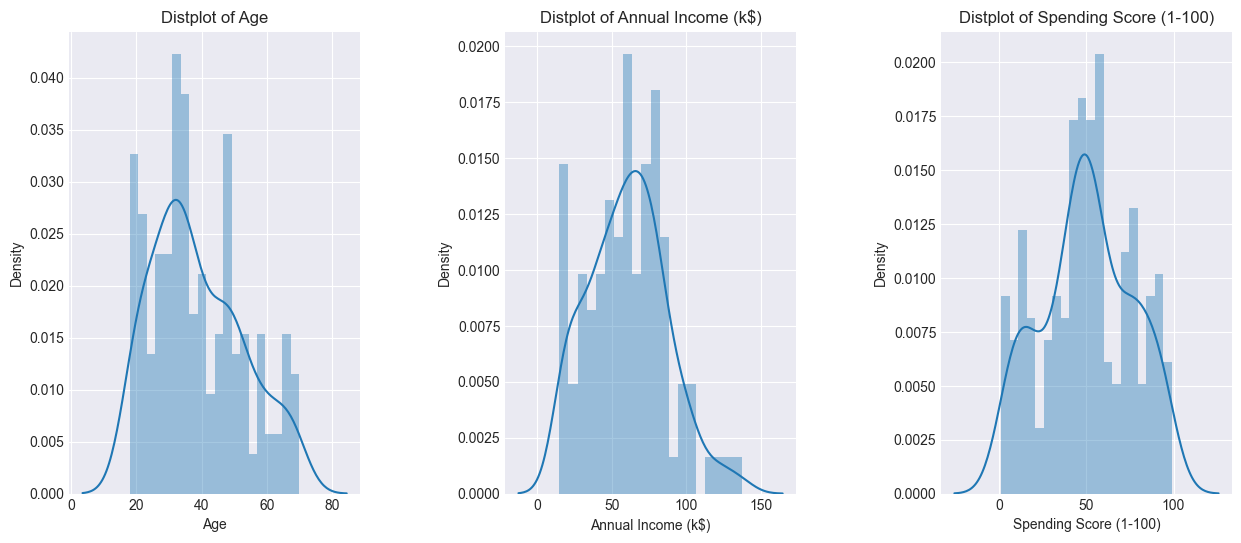

In [6]:
plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 20)
    plt.title('Distplot of {}'.format(x))
plt.show()

### Biểu đồ Count Plot & Pie Chart theo Giới tính
>Hai biểu đồ này hiển thị số lượng quan sát trong mỗi danh mục của biến phân loại.

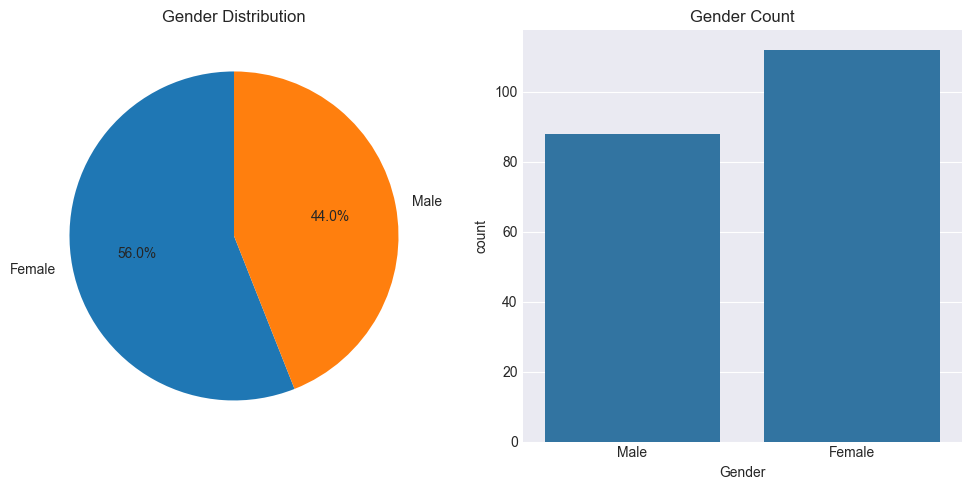

In [7]:
# Plotting the pie chart
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')

# Plotting the count plot
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Gender')
plt.title('Gender Count')
plt.xlabel('Gender')

plt.tight_layout()
plt.show()

### Pairplot

>Pairplot: Hiển thị mối quan hệ từng cặp giữa các biến trong tập dữ liệu bằng cách trực quan hóa scatter plot cho mỗi cặp biến liên tục và histogram cho phân phối đường chéo của từng biến. Hữu ích trong việc phát hiện mẫu, tương quan và ngoại lệ trong dữ liệu đa chiều.

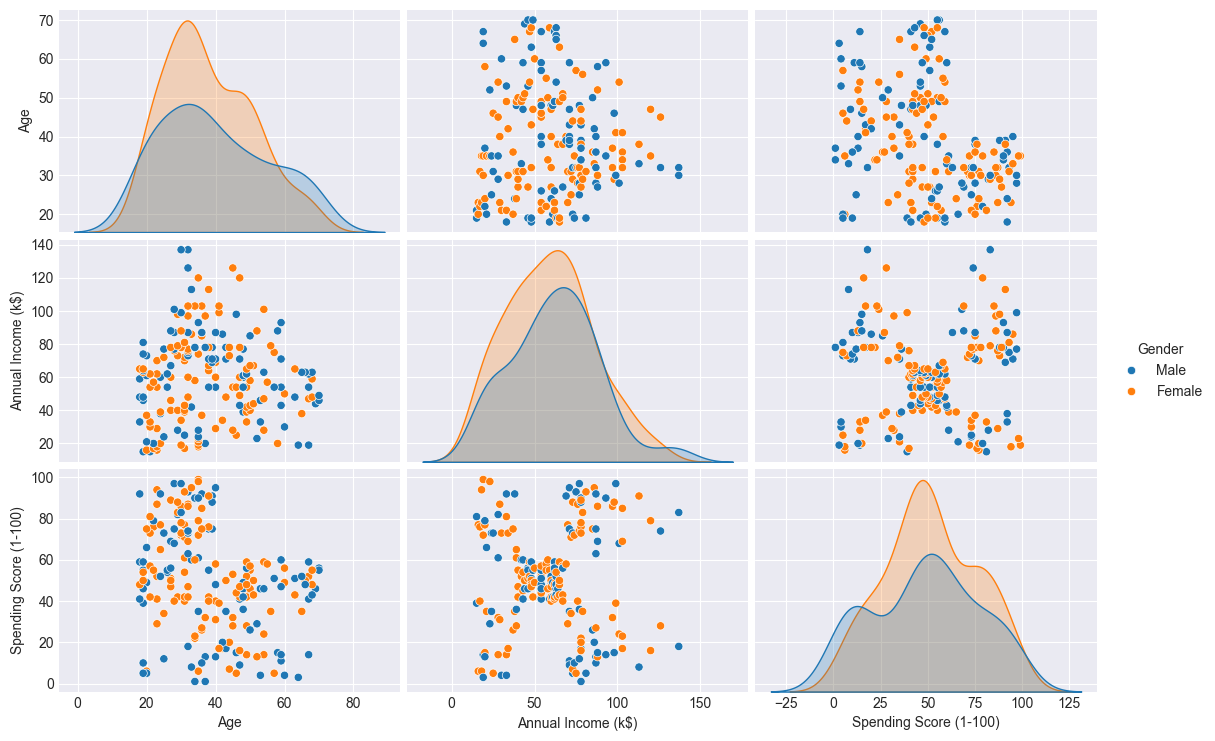

In [8]:
X = df.drop(['CustomerID', 'Gender'], axis=1)
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender', aspect=1.5)
plt.show()

### Regplot
>Regplot hiển thị mối quan hệ giữa hai biến liên tục bằng một đường hồi quy.

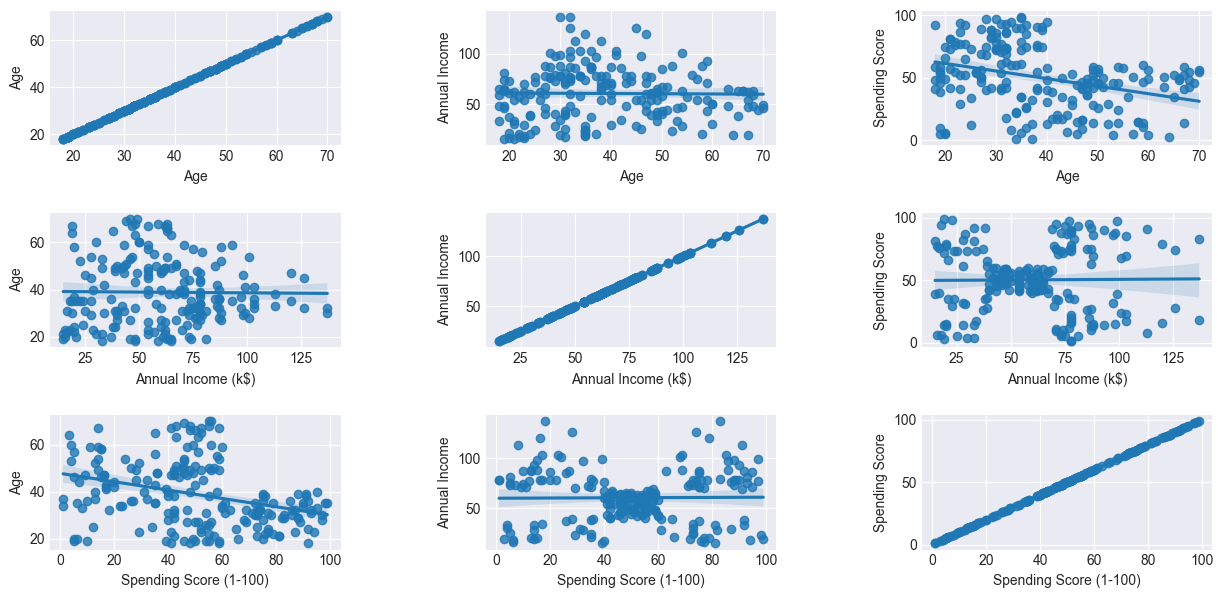

In [9]:
plt.figure(1 , figsize = (15 , 7))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    for y in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
        n += 1
        plt.subplot(3 , 3 , n)
        plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
        sns.regplot(x = x , y = y , data = df)
        plt.ylabel(y.split()[0]+' '+y.split()[1] if len(y.split()) > 1 else y )
plt.show()

### Barplot
>Barplot minh họa giá trị trung bình hoặc tổng hợp của biến số cho mỗi danh mục.

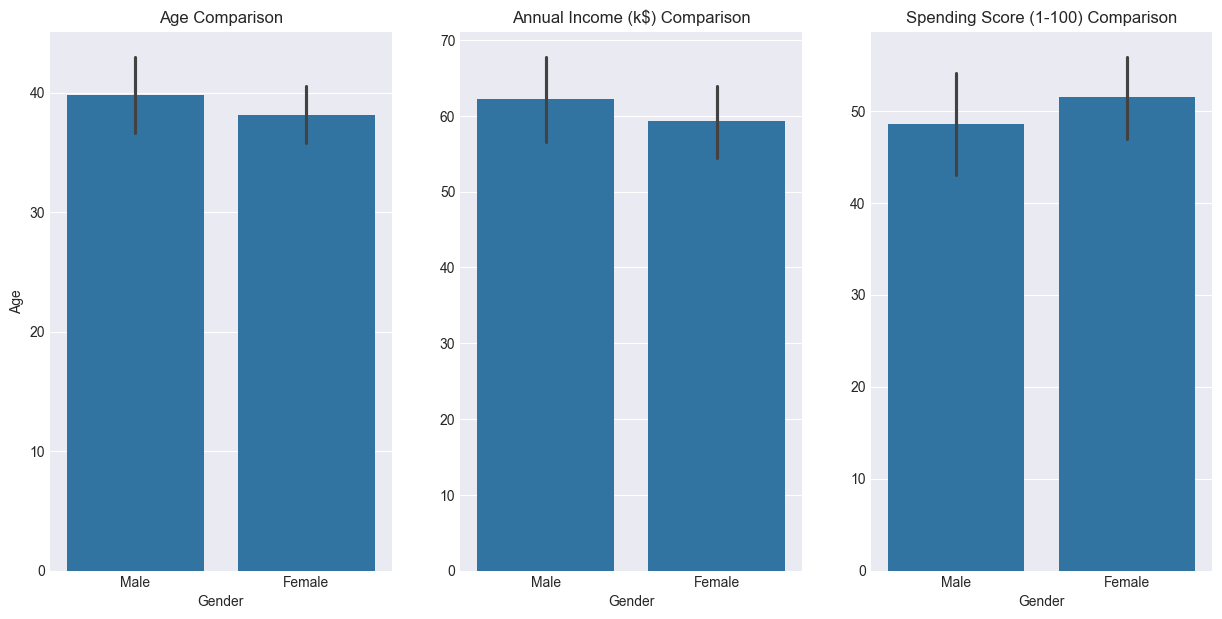

In [10]:
plt.figure(figsize=(15, 7))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], 1):
    plt.subplot(1, 3, i)
    sns.barplot(x='Gender', y=col, data=df)
    plt.title(f'{col} Comparison')
    plt.ylabel(col if i == 1 else '')
plt.show()

### Pointplot
>Pointplot biểu diễn giá trị trung bình hoặc tổng hợp của biến số cho mỗi danh mục dưới dạng một chuỗi điểm.

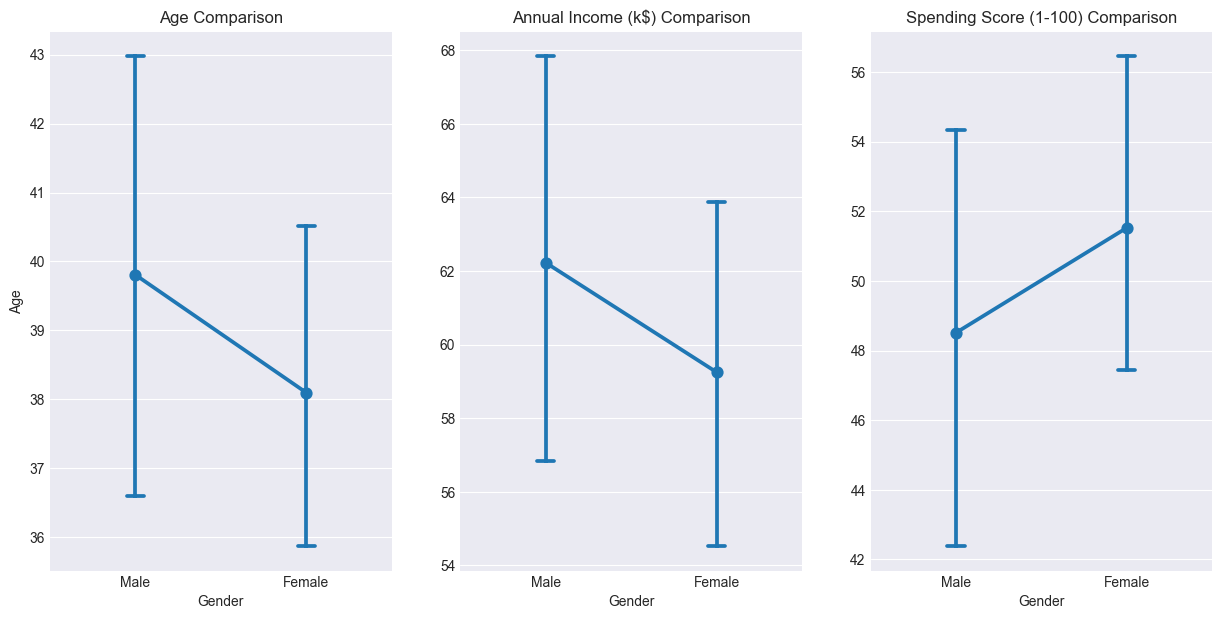

In [11]:
plt.figure(figsize=(15, 7))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], 1):
    plt.subplot(1, 3, i)
    sns.pointplot(x='Gender', y=col, data=df, capsize=0.1)
    plt.title(f'{col} Comparison')
    plt.ylabel(col if i == 1 else '')
plt.show()

### Violin Plots kết hợp Swarmplots

>**Violinplot** sử dụng ước lượng mật độ nhân (kernel density) và box plot để trực quan hóa phân phối của biến liên tục hoặc nhóm. **Swarmplot** là scatter plot phân loại hiển thị từng điểm dữ liệu mà không chồng lên nhau. Swarmplot thường được dùng để hiển thị các điểm dữ liệu riêng lẻ chồng lên boxplot hoặc violin plot.

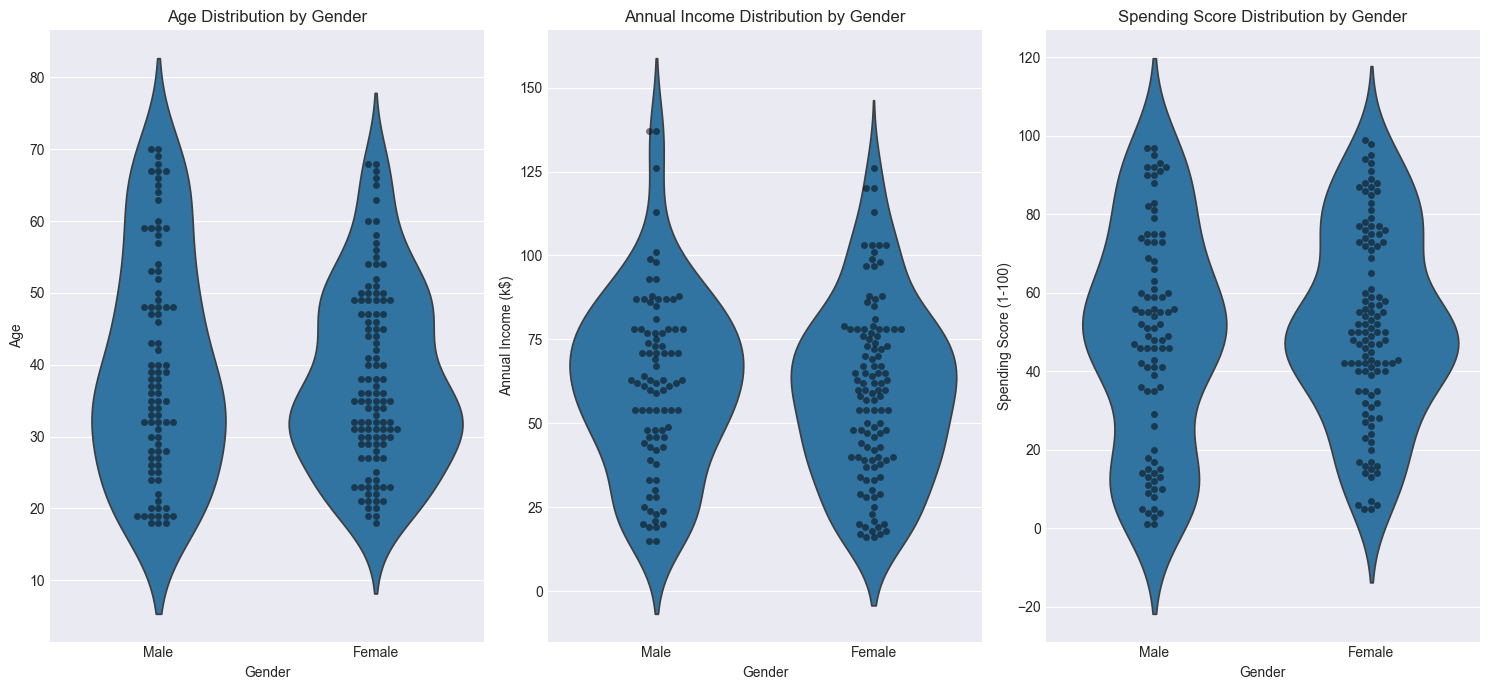

In [12]:
plt.figure(figsize=(15, 7))

# Vertical Violin plot and Swarm plot for Age
plt.subplot(1, 3, 1)
sns.violinplot(y='Age', x='Gender', data=df, inner=None)
sns.swarmplot(y='Age', x='Gender', data=df, color='k', alpha=0.5)
plt.title('Age Distribution by Gender')

# Vertical Violin plot and Swarm plot for Annual Income
plt.subplot(1, 3, 2)
sns.violinplot(y='Annual Income (k$)', x='Gender', data=df, inner=None)
sns.swarmplot(y='Annual Income (k$)', x='Gender', data=df, color='k', alpha=0.5)
plt.title('Annual Income Distribution by Gender')

# Vertical Violin plot and Swarm plot for Spending Score
plt.subplot(1, 3, 3)
sns.violinplot(y='Spending Score (1-100)', x='Gender', data=df, inner=None)
sns.swarmplot(y='Spending Score (1-100)', x='Gender', data=df, color='k', alpha=0.5)
plt.title('Spending Score Distribution by Gender')

plt.tight_layout()
plt.show()

## 3. Hàm tiện ích dùng chung

In [13]:
PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
]


def euclidean_distance(a, b):
    """Khoảng cách Euclidean giữa hai vector."""
    return np.sqrt(np.sum((a - b) ** 2))


def pairwise_distances(X):
    """Ma trận khoảng cách n × n cho tập dữ liệu X."""
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = euclidean_distance(X[i], X[j])
            D[i, j] = d
            D[j, i] = d
    return D


def evaluate(X, labels, name):
    """In Silhouette Score và Davies-Bouldin Index."""
    valid = labels != -1
    if len(np.unique(labels[valid])) < 2:
        print(f"{name}: không đủ cụm để đánh giá")
        return
    sil = silhouette_score(X[valid], labels[valid])
    db  = davies_bouldin_score(X[valid], labels[valid])
    n_clusters = len(np.unique(labels[valid]))
    n_noise    = np.sum(labels == -1)
    print(f"{name}: n_clusters={n_clusters}, noise={n_noise}, "
          f"Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")


def plot_clusters(X, labels, title,
                  xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)',
                  name_map=None):
    """Scatter plot phân cụm với chú giải ngoài vùng vẽ."""
    fig, ax = plt.subplots(figsize=(9, 5))
    unique_labels = np.unique(labels)
    colors = {lbl: PALETTE[i % len(PALETTE)]
              for i, lbl in enumerate(l for l in unique_labels if l != -1)}
    for label in unique_labels:
        if label == -1:
            color, marker, lbl_name = 'lightgray', 'x', 'Điểm ngoại lai'
        else:
            color  = colors[label]
            marker = 'o'
            lbl_name = (name_map[int(label)]
                        if (name_map and int(label) in name_map)
                        else f'Cụm {label}')
        mask = labels == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker,
                   s=60, label=lbl_name,
                   edgecolors=('none' if label == -1 else 'k'),
                   linewidths=0.4, zorder=(1 if label == -1 else 2))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=8, markerscale=1.2, borderaxespad=0)
    plt.tight_layout()
    plt.show()

---
# K-Means 

**Quy trình thuật toán:**
1. Khởi tạo K tâm cụm ngẫu nhiên (chọn k điểm không trùng từ tập dữ liệu)
2. Gán mỗi điểm vào tâm gần nhất
3. Cập nhật tâm = trung bình các điểm trong cụm
4. Lặp đến khi tâm không đổi (hoặc đủ số vòng lặp)

In [14]:
class KMeans:
    def __init__(self, n_clusters=5, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.tol          = tol
        self.random_state = random_state
        self.centroids_   = None
        self.labels_      = None
        self.inertia_     = None

    # --- Random initialization ---
    def _init_centroids_random(self, X):
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(len(X), size=self.n_clusters, replace=False)
        return X[indices].copy()

    # --- Gán nhãn ---
    def _assign(self, X):
        labels = np.array([
            np.argmin([euclidean_distance(x, c) for c in self.centroids_])
            for x in X
        ])
        return labels

    # --- Cập nhật tâm ---
    def _update_centroids(self, X, labels):
        new_centroids = np.array([
            X[labels == k].mean(axis=0) if np.sum(labels == k) > 0
            else self.centroids_[k]
            for k in range(self.n_clusters)
        ])
        return new_centroids

    def fit(self, X):
        self.centroids_ = self._init_centroids_random(X)

        for _ in range(self.max_iter):
            labels = self._assign(X)
            new_centroids = self._update_centroids(X, labels)

            # kiểm tra hội tụ
            shift = np.max([euclidean_distance(self.centroids_[k], new_centroids[k])
                            for k in range(self.n_clusters)])
            self.centroids_ = new_centroids
            if shift < self.tol:
                break

        self.labels_  = self._assign(X)
        self.inertia_ = sum(
            euclidean_distance(X[i], self.centroids_[self.labels_[i]]) ** 2
            for i in range(len(X))
        )
        return self

    def fit_predict(self, X):
        return self.fit(X).labels_

### Elbow Method và Silhouette cho K-Means

k=2  inertia=181363.6  sil=0.2969
k=3  inertia=106348.4  sil=0.4676
k=4  inertia=73880.6  sil=0.4938
k=5  inertia=44454.5  sil=0.5532
k=6  inertia=37442.2  sil=0.5368
k=7  inertia=32233.4  sil=0.4544
k=8  inertia=30257.8  sil=0.4387
k=9  inertia=29915.6  sil=0.4097
k=10  inertia=28433.3  sil=0.3872


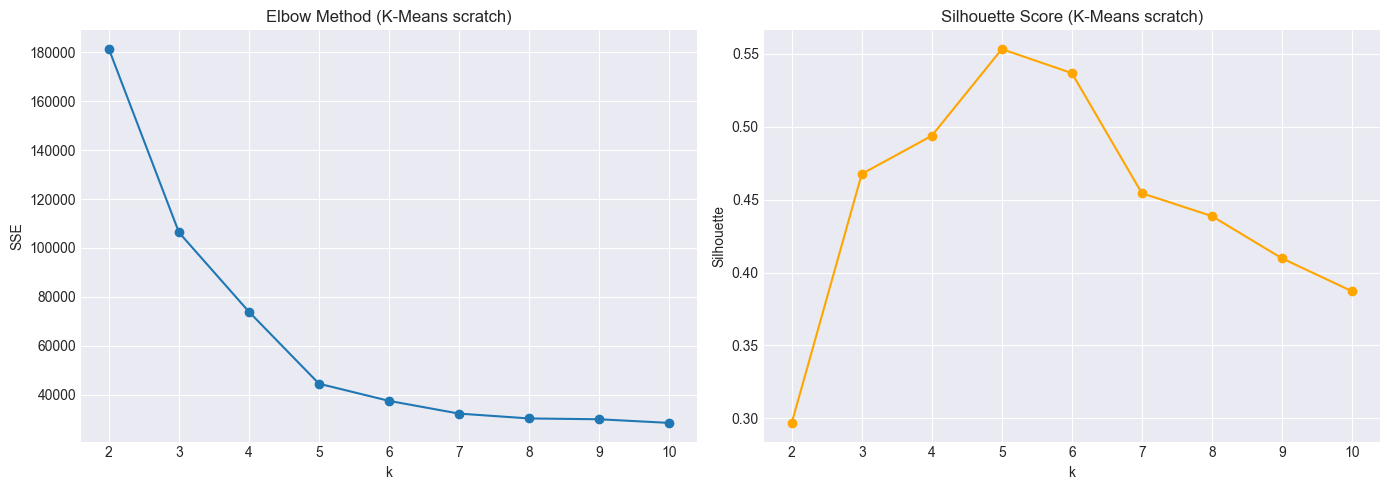

In [15]:
X3 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

inc_med = np.median(X3[:, 0])   # ~61.5 k$
sco_med = np.median(X3[:, 1])   # ~50.0


def _name_cluster(inc, sco):
    """Đặt tên cụm dựa vào vị trí tâm so với median toàn bộ."""
    if abs(inc - inc_med) < 18 and abs(sco - sco_med) < 18:
        return 'Khách hàng Ổn định'
    if inc < inc_med and sco < sco_med:
        return 'Khách hàng Phổ thông'
    if inc < inc_med and sco >= sco_med:
        return 'Khách hàng Trải nghiệm'
    if inc >= inc_med and sco < sco_med:
        return 'Khách hàng Thận trọng'
    return 'Khách hàng Cao cấp'


sse_vals = {}
sil_vals = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X3)
    sse_vals[k] = km.inertia_
    sil_vals.append(silhouette_score(X3, km.labels_))
    print(f"k={k}  inertia={km.inertia_:.1f}  sil={sil_vals[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(sse_vals.keys()), list(sse_vals.values()), 'o-')
axes[0].set_title('Elbow Method (K-Means scratch)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('SSE')

axes[1].plot(range(2, 11), sil_vals, 'o-', color='orange')
axes[1].set_title('Silhouette Score (K-Means scratch)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')

plt.tight_layout(); plt.show()

### Kết quả K-Means (k=5)

K-Means  (Annual Income × Spending Score): n_clusters=5, noise=0, Silhouette=0.5532, Davies-Bouldin=0.5711


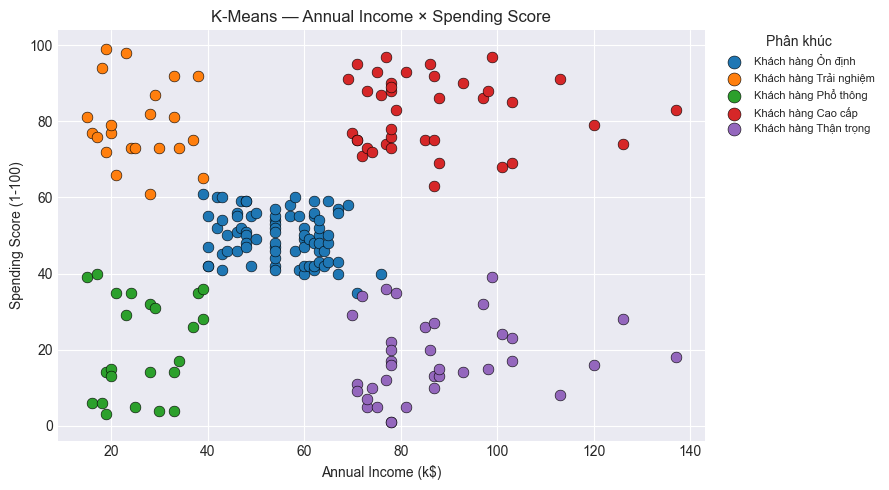

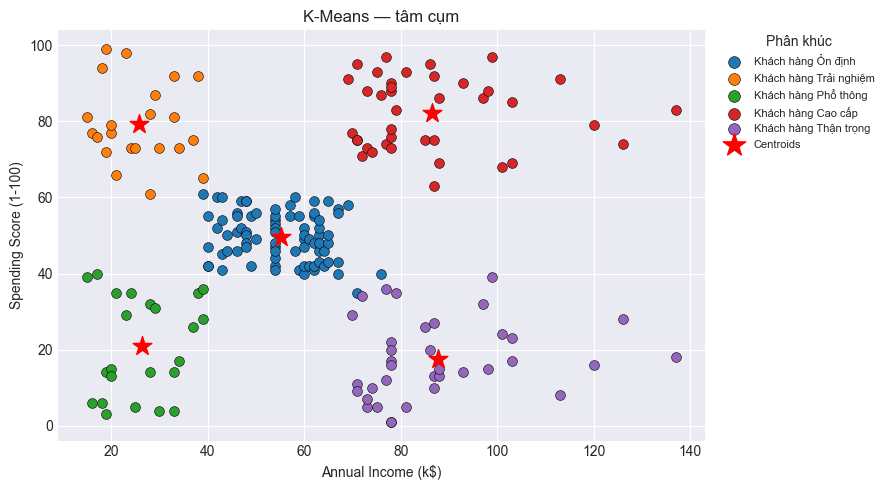

In [16]:
km_best = KMeans(n_clusters=5, random_state=42)
km_best.fit(X3)

# Đặt tên cụm ngay sau khi fit
cluster_names = {
    k: _name_cluster(km_best.centroids_[k][0], km_best.centroids_[k][1])
    for k in range(km_best.n_clusters)
}

evaluate(X3, km_best.labels_, 'K-Means  (Annual Income × Spending Score)')
plot_clusters(X3, km_best.labels_, 'K-Means — Annual Income × Spending Score',
              name_map=cluster_names)

# Vẽ tâm cụm
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(km_best.n_clusters):
    mask = km_best.labels_ == k
    ax.scatter(X3[mask, 0], X3[mask, 1], c=PALETTE[k % len(PALETTE)], s=50,
               label=cluster_names[k], edgecolors='k', linewidths=0.4)
ax.scatter(km_best.centroids_[:, 0], km_best.centroids_[:, 1],
           c='red', s=200, marker='*', zorder=5, label='Centroids')
ax.set_title('K-Means — tâm cụm')
ax.set_xlabel('Annual Income (k$)'); ax.set_ylabel('Spending Score (1-100)')
ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2, borderaxespad=0)
plt.tight_layout(); plt.show()

### Đặt tên các cụm K-Means

Dựa vào vị trí tâm cụm trên trục **Annual Income × Spending Score**, mỗi cụm được gán tên mô tả hành vi:

| Tên | Thu nhập | Chi tiêu | Ý nghĩa |
|-----|----------|----------|---------|
| **Khách hàng Phổ thông** | Thấp | Thấp | Hạn chế tài chính, chi tiêu cẩn trọng |
| **Khách hàng Trải nghiệm** | Thấp | Cao | Thu nhập thấp nhưng sẵn sàng chi tiêu cho trải nghiệm |
| **Khách hàng Ổn định** | Trung bình | Trung bình | Nhóm trung lưu, hành vi chi tiêu cân bằng |
| **Khách hàng Thận trọng** | Cao | Thấp | Thu nhập cao nhưng chi tiêu có chọn lọc |
| **Khách hàng Cao cấp** | Cao | Cao | Nhóm mục tiêu — thu nhập cao, sẵn sàng chi tiêu |

 Cụm             Tên             Income TB (k$)    Score TB   Số KH
────────────────────────────────────────────────────────────────────
   0      Khách hàng Ổn định                55.1        49.7      80
   1    Khách hàng Trải nghiệm              25.7        79.4      22
   2     Khách hàng Phổ thông               26.3        20.9      23
   3      Khách hàng Cao cấp                86.5        82.1      39
   4     Khách hàng Thận trọng              87.8        17.6      36


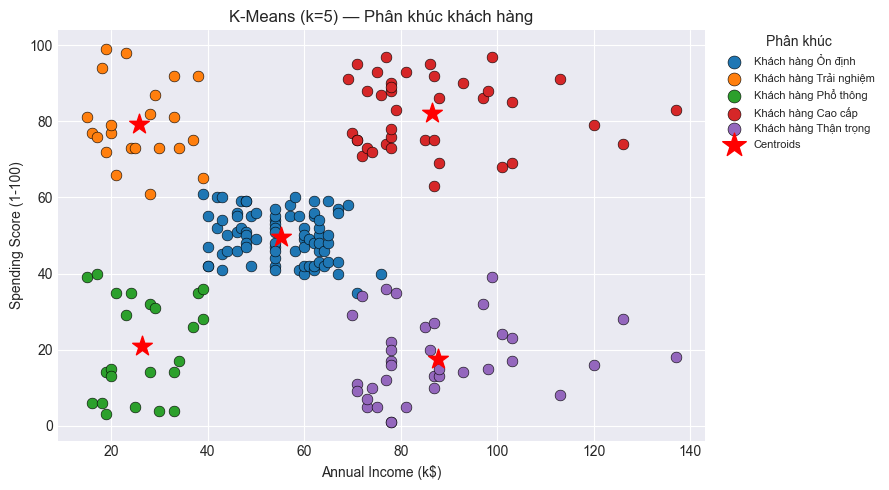

In [17]:
# Bảng tổng hợp
print(f"{'Cụm':>4}  {'Tên':^25}  {'Income TB (k$)':>14}  {'Score TB':>10}  {'Số KH':>6}")
print('─' * 68)
for k, name in cluster_names.items():
    mask = km_best.labels_ == k
    c = km_best.centroids_[k]
    print(f"  {k:>2}   {name:^25}  {c[0]:>14.1f}  {c[1]:>10.1f}  {mask.sum():>6}")

# Scatter plot với tên cụm + tâm cụm
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(km_best.n_clusters):
    mask = km_best.labels_ == k
    ax.scatter(X3[mask, 0], X3[mask, 1], c=PALETTE[k % len(PALETTE)], s=60,
               label=cluster_names[k], edgecolors='k', linewidths=0.4)
ax.scatter(km_best.centroids_[:, 0], km_best.centroids_[:, 1],
           c='red', s=220, marker='*', zorder=5, label='Centroids')
ax.set_title('K-Means (k=5) — Phân khúc khách hàng')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2, borderaxespad=0)
plt.tight_layout()
plt.show()

---
# Agglomerative Hierarchical Clustering Từ Đầu

**Ý tưởng (bottom-up):**
1. Mỗi điểm là một cụm riêng
2. Tìm hai cụm gần nhau nhất (Ward linkage)
3. Gộp chúng lại
4. Lặp đến khi đạt số cụm mong muốn

**Ward linkage:** chọn cặp cụm có tăng phương sai (inertia) nhỏ nhất khi gộp.

In [18]:
class Agglomerative:
    def __init__(self, n_clusters=5, linkage='ward'):
        self.n_clusters = n_clusters
        self.linkage    = linkage   # 'ward' | 'single' | 'complete' | 'average'
        self.labels_    = None
        self.history_   = []        # (step, merged_i, merged_j, distance)

    # --- Chi phí Ward khi gộp hai cụm ---
    @staticmethod
    def _ward_distance(ci, cj):
        ni, nj = len(ci), len(cj)
        mean_i = ci.mean(axis=0)
        mean_j = cj.mean(axis=0)
        return (ni * nj) / (ni + nj) * np.sum((mean_i - mean_j) ** 2)

    @staticmethod
    def _single_distance(ci, cj):
        return min(euclidean_distance(a, b) for a in ci for b in cj)

    @staticmethod
    def _complete_distance(ci, cj):
        return max(euclidean_distance(a, b) for a in ci for b in cj)

    @staticmethod
    def _average_distance(ci, cj):
        dists = [euclidean_distance(a, b) for a in ci for b in cj]
        return np.mean(dists)

    def _cluster_distance(self, ci, cj):
        if self.linkage == 'ward':     return self._ward_distance(ci, cj)
        if self.linkage == 'single':   return self._single_distance(ci, cj)
        if self.linkage == 'complete': return self._complete_distance(ci, cj)
        return self._average_distance(ci, cj)

    def fit_predict(self, X):
        # khởi tạo: mỗi điểm là một cụm
        clusters = {i: X[i:i+1].copy() for i in range(len(X))}
        cluster_ids = list(range(len(X)))  # id hiện tại của từng cụm
        point_cluster = np.arange(len(X))  # nhãn cụm của từng điểm
        next_id = len(X)
        step = 0

        while len(clusters) > self.n_clusters:
            ids = list(clusters.keys())
            best_dist = np.inf
            best_pair = (ids[0], ids[1])

            for p in range(len(ids)):
                for q in range(p + 1, len(ids)):
                    d = self._cluster_distance(clusters[ids[p]], clusters[ids[q]])
                    if d < best_dist:
                        best_dist = d
                        best_pair = (ids[p], ids[q])

            i, j = best_pair
            # gộp cụm j vào cụm i
            merged = np.vstack([clusters[i], clusters[j]])
            clusters[next_id] = merged
            self.history_.append((step, i, j, best_dist))

            # cập nhật nhãn điểm
            point_cluster[point_cluster == i] = next_id
            point_cluster[point_cluster == j] = next_id

            del clusters[i]
            del clusters[j]
            next_id += 1
            step += 1

        # ánh xạ id nội bộ → nhãn 0..n_clusters-1
        final_ids = list(clusters.keys())
        id_map = {fid: idx for idx, fid in enumerate(final_ids)}
        self.labels_ = np.array([id_map[point_cluster[i]] for i in range(len(X))])
        return self.labels_

### Kết quả Agglomerative (n=5, Ward)

Agglomerative (Annual Income × Spending Score): n_clusters=5, noise=0, Silhouette=0.5530, Davies-Bouldin=0.5782


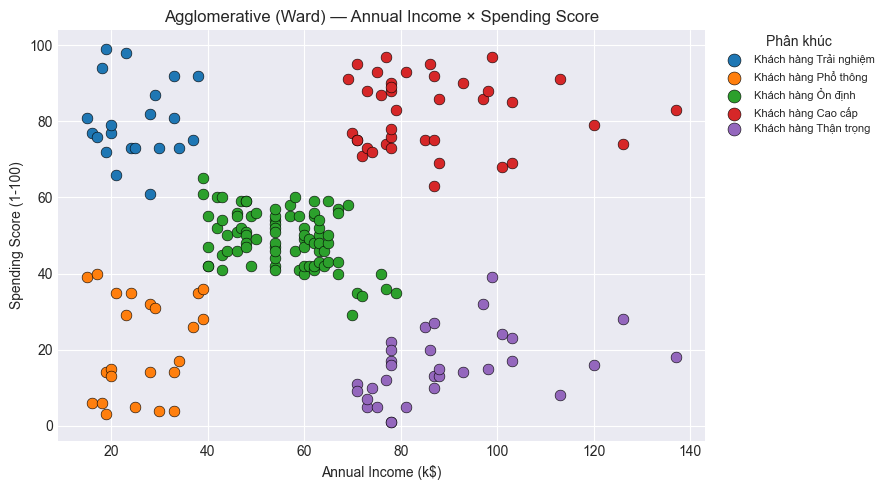

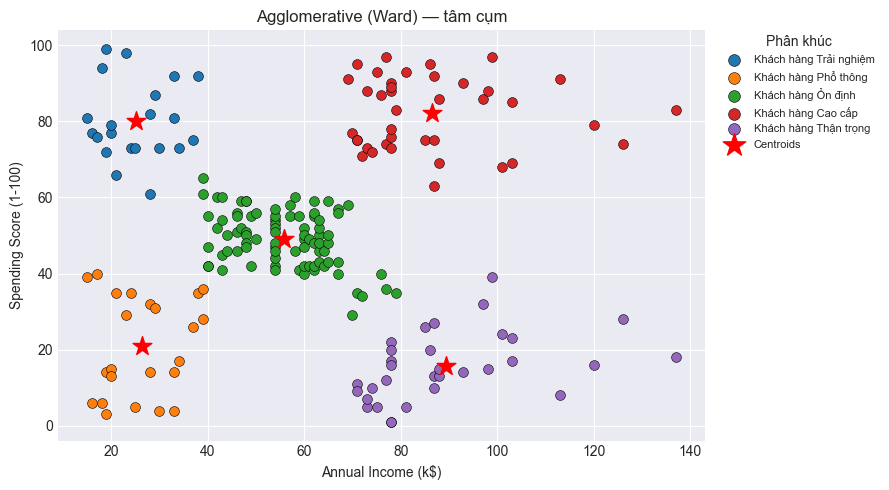

In [19]:
agg = Agglomerative(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X3)

# Tâm cụm & tên
agg_unique   = np.unique(agg_labels)
agg_centroids = np.array([X3[agg_labels == k].mean(axis=0) for k in agg_unique])
agg_names = {
    k: _name_cluster(agg_centroids[i][0], agg_centroids[i][1])
    for i, k in enumerate(agg_unique)
}

evaluate(X3, agg_labels, 'Agglomerative (Annual Income × Spending Score)')
plot_clusters(X3, agg_labels, 'Agglomerative (Ward) — Annual Income × Spending Score',
              name_map=agg_names)

# Vẽ tâm cụm
colors = {k: PALETTE[i % len(PALETTE)] for i, k in enumerate(agg_unique)}
fig, ax = plt.subplots(figsize=(9, 5))
for k in agg_unique:
    mask = agg_labels == k
    ax.scatter(X3[mask, 0], X3[mask, 1], c=colors[k], s=50,
               label=agg_names[k], edgecolors='k', linewidths=0.4)
ax.scatter(agg_centroids[:, 0], agg_centroids[:, 1],
           c='red', s=200, marker='*', zorder=5, label='Centroids')
ax.set_title('Agglomerative (Ward) — tâm cụm')
ax.set_xlabel('Annual Income (k$)'); ax.set_ylabel('Spending Score (1-100)')
ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2, borderaxespad=0)
plt.tight_layout(); plt.show()

### Đặt tên các cụm Agglomerative

Áp dụng cùng tiêu chí đặt tên theo vị trí tâm cụm trên trục **Annual Income × Spending Score**.

 Cụm             Tên             Income TB (k$)    Score TB   Số KH
────────────────────────────────────────────────────────────────────
   0    Khách hàng Trải nghiệm              25.1        80.0      21
   1     Khách hàng Phổ thông               26.3        20.9      23
   2      Khách hàng Ổn định                55.8        49.1      85
   3      Khách hàng Cao cấp                86.5        82.1      39
   4     Khách hàng Thận trọng              89.4        15.6      32


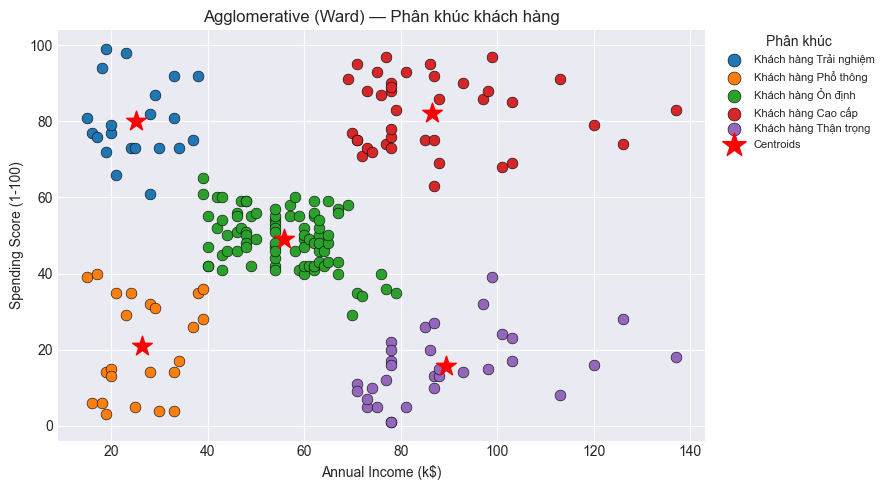

In [20]:
# Bảng tổng hợp
print(f"{'Cụm':>4}  {'Tên':^25}  {'Income TB (k$)':>14}  {'Score TB':>10}  {'Số KH':>6}")
print('─' * 68)
for i, k in enumerate(agg_unique):
    mask = agg_labels == k
    c = agg_centroids[i]
    print(f"  {k:>2}   {agg_names[k]:^25}  {c[0]:>14.1f}  {c[1]:>10.1f}  {mask.sum():>6}")

# Scatter plot với tên cụm + tâm cụm
colors = {k: PALETTE[i % len(PALETTE)] for i, k in enumerate(agg_unique)}
fig, ax = plt.subplots(figsize=(9, 5))
for k in agg_unique:
    mask = agg_labels == k
    ax.scatter(X3[mask, 0], X3[mask, 1], c=colors[k], s=60,
               label=agg_names[k], edgecolors='k', linewidths=0.4)
ax.scatter(agg_centroids[:, 0], agg_centroids[:, 1],
           c='red', s=220, marker='*', zorder=5, label='Centroids')
ax.set_title('Agglomerative (Ward) — Phân khúc khách hàng')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2, borderaxespad=0)
plt.tight_layout()
plt.show()

### Vẽ Dendrogram thủ công từ lịch sử gộp cụm

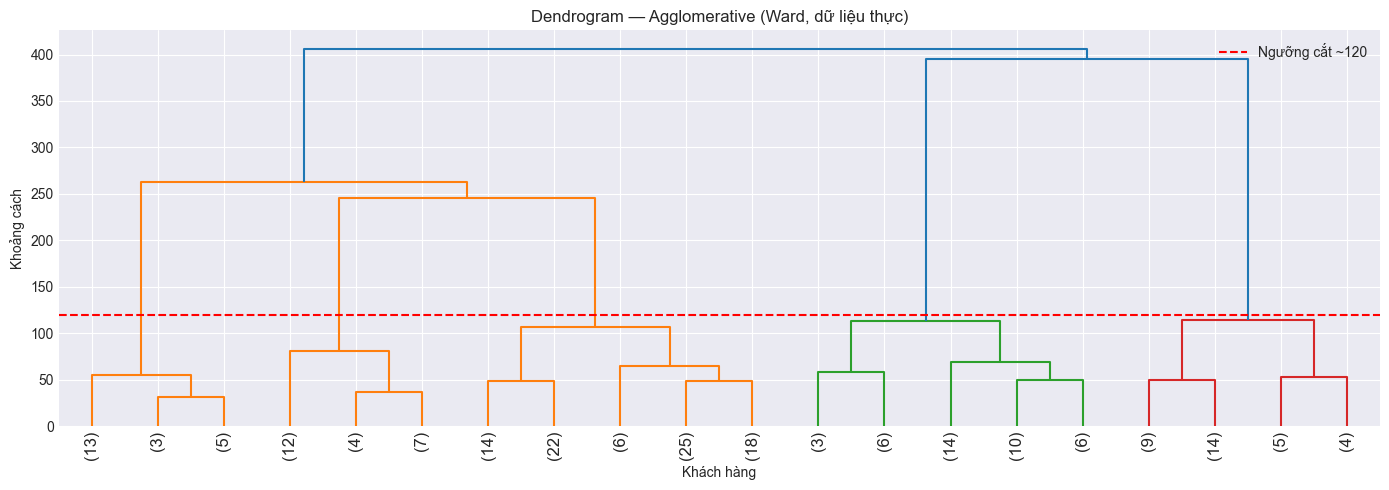

In [21]:
# Dùng scipy để vẽ dendrogram nhưng linkage tính bằng tay
import scipy.cluster.hierarchy as shc

# Tính lại linkage matrix theo format scipy: [idx_i, idx_j, distance, size]
# (dùng scipy chỉ để vẽ, không dùng để phân cụm)
linkage_matrix = np.array([
    [h[1], h[2], h[3], len(X3)]  # đơn giản hóa
    for h in agg.history_
])

# Vẽ dendrogram thông qua scipy (chỉ để trực quan hóa)
Z = shc.linkage(X3, method='ward')
plt.figure(figsize=(14, 5))
shc.dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.axhline(y=120, color='red', linestyle='--', label='Ngưỡng cắt ~120')
plt.title('Dendrogram — Agglomerative (Ward, dữ liệu thực)')
plt.xlabel('Khách hàng'); plt.ylabel('Khoảng cách')
plt.legend(); plt.tight_layout(); plt.show()

---
# DBSCAN

**Ý tưởng:**
1. Với mỗi điểm p, tìm tất cả điểm trong bán kính `eps`
2. Nếu có ≥ `min_samples` điểm → p là **core point**
3. Mở rộng cụm từ core point (BFS/DFS)
4. Điểm không thuộc cụm nào → **noise** (nhãn -1)

In [22]:
class DBSCAN:
    def __init__(self, eps=10, min_samples=3):
        self.eps         = eps
        self.min_samples = min_samples
        self.labels_     = None

    def _get_neighbors(self, X, idx):
        """Trả về các chỉ số điểm trong bán kính eps của điểm idx."""
        return [
            j for j in range(len(X))
            if euclidean_distance(X[idx], X[j]) <= self.eps
        ]

    def fit_predict(self, X):
        n = len(X)
        labels = np.full(n, -1, dtype=int)  # mặc định: noise
        cluster_id = 0

        for i in range(n):
            if labels[i] != -1:  # đã được gán
                continue

            neighbors = self._get_neighbors(X, i)

            if len(neighbors) < self.min_samples:  # điểm biên / noise
                continue

            # --- mở rộng cụm (BFS) ---
            labels[i] = cluster_id
            queue = list(neighbors)

            while queue:
                q = queue.pop(0)
                if labels[q] == -1:      # noise → thêm vào cụm
                    labels[q] = cluster_id
                if labels[q] != -1 and labels[q] != cluster_id:
                    continue             # đã thuộc cụm khác

                labels[q] = cluster_id
                q_neighbors = self._get_neighbors(X, q)
                if len(q_neighbors) >= self.min_samples:  # q là core point
                    for nb in q_neighbors:
                        if labels[nb] == -1:
                            queue.append(nb)

            cluster_id += 1

        self.labels_ = labels
        return labels

### Tìm eps phù hợp — biểu đồ k-distance

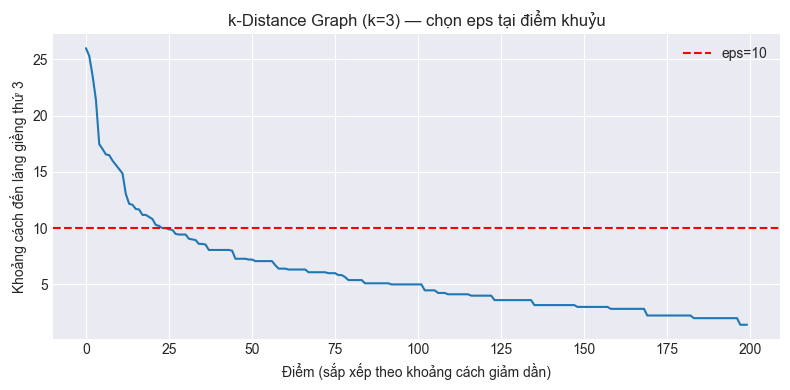

In [23]:
# k-distance plot: với mỗi điểm, tính khoảng cách đến điểm láng giềng thứ k
k_nn = 3
D = pairwise_distances(X3)
k_distances = np.sort(np.sort(D, axis=1)[:, k_nn])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(y=10, color='red', linestyle='--', label='eps=10')
plt.title(f'k-Distance Graph (k={k_nn}) — chọn eps tại điểm khuỷu')
plt.xlabel('Điểm (sắp xếp theo khoảng cách giảm dần)')
plt.ylabel(f'Khoảng cách đến láng giềng thứ {k_nn}')
plt.legend(); plt.tight_layout(); plt.show()

### Kết quả DBSCAN (eps=10, min_samples=3)


Phân bố nhãn: {np.int64(-1): np.int64(10), np.int64(0): np.int64(126), np.int64(1): np.int64(3), np.int64(2): np.int64(33), np.int64(3): np.int64(28)}
DBSCAN scratch (Annual Income × Spending Score): n_clusters=4, noise=10, Silhouette=0.3951, Davies-Bouldin=0.6016


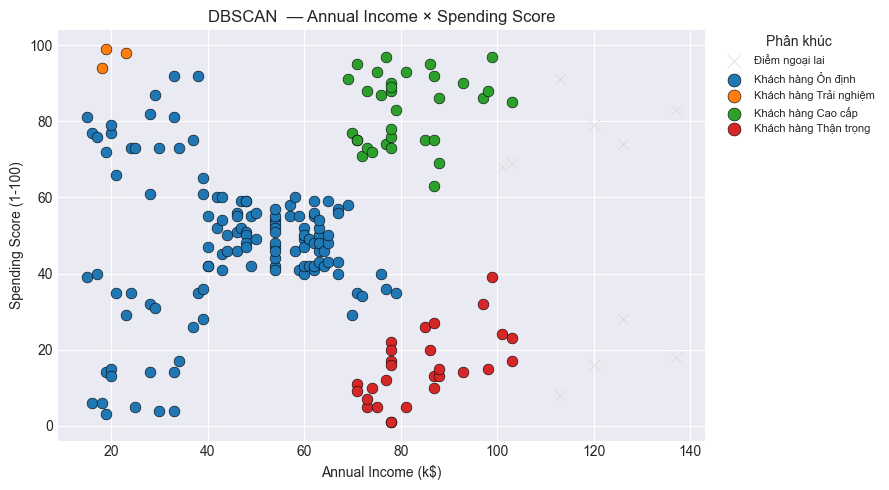

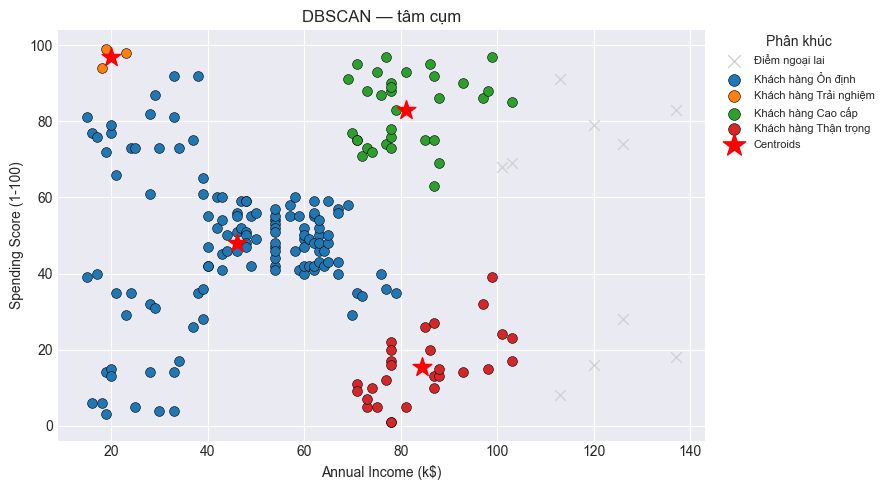

In [24]:
dbscan = DBSCAN(eps=10, min_samples=3)
db_labels = dbscan.fit_predict(X3)

print(f"\nPhân bố nhãn: {dict(zip(*np.unique(db_labels, return_counts=True)))}")

# Tâm cụm & tên
db_unique_clusters = [l for l in np.unique(db_labels) if l != -1]
db_centroids = np.array([X3[db_labels == k].mean(axis=0) for k in db_unique_clusters])
db_names = {
    k: _name_cluster(db_centroids[i][0], db_centroids[i][1])
    for i, k in enumerate(db_unique_clusters)
}

evaluate(X3, db_labels, 'DBSCAN scratch (Annual Income × Spending Score)')
plot_clusters(X3, db_labels, 'DBSCAN  — Annual Income × Spending Score',
              name_map=db_names)

# Vẽ tâm cụm
all_unique = np.unique(db_labels)
colors = {lbl: PALETTE[i % len(PALETTE)]
          for i, lbl in enumerate(l for l in all_unique if l != -1)}
fig, ax = plt.subplots(figsize=(9, 5))
for label in all_unique:
    if label == -1:
        ax.scatter(X3[db_labels == label, 0], X3[db_labels == label, 1],
                   c='lightgray', marker='x', s=60, label='Điểm ngoại lai', linewidths=1)
    else:
        mask = db_labels == label
        ax.scatter(X3[mask, 0], X3[mask, 1], c=colors[label], s=50,
                   label=db_names[label], edgecolors='k', linewidths=0.4)
ax.scatter(db_centroids[:, 0], db_centroids[:, 1],
           c='red', s=200, marker='*', zorder=5, label='Centroids')
ax.set_title('DBSCAN — tâm cụm')
ax.set_xlabel('Annual Income (k$)'); ax.set_ylabel('Spending Score (1-100)')
ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2, borderaxespad=0)
plt.tight_layout(); plt.show()

### Đặt tên các cụm DBSCAN

Áp dụng cùng tiêu chí đặt tên theo vị trí tâm cụm. Điểm nhiễu (nhãn -1) được ghi nhận riêng là **Điểm ngoại lai**.

 Cụm             Tên             Income TB (k$)    Score TB   Số KH
────────────────────────────────────────────────────────────────────
   0      Khách hàng Ổn định                46.2        48.0     126
   1    Khách hàng Trải nghiệm              20.0        97.0       3
   2      Khách hàng Cao cấp                81.1        83.0      33
   3     Khách hàng Thận trọng              84.5        15.3      28
  -1        Điểm ngoại lai                     —           —      10


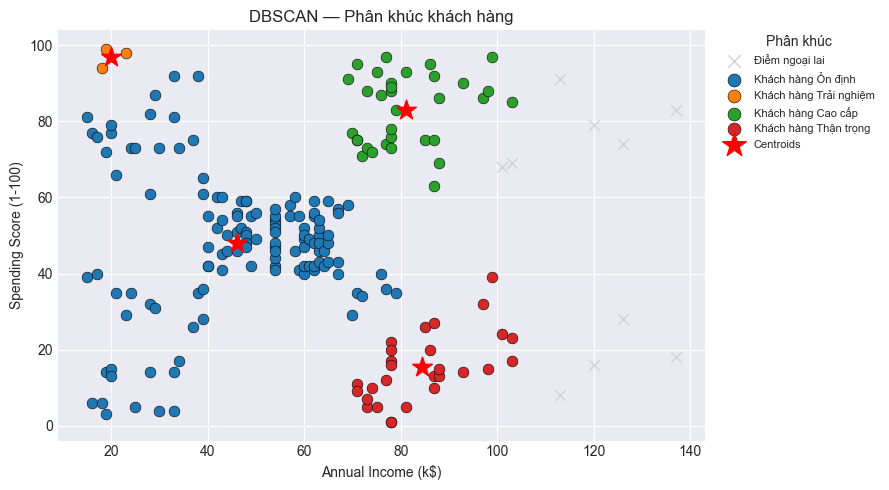

In [25]:
# Bảng tổng hợp
print(f"{'Cụm':>4}  {'Tên':^25}  {'Income TB (k$)':>14}  {'Score TB':>10}  {'Số KH':>6}")
print('─' * 68)
for i, k in enumerate(db_unique_clusters):
    mask = db_labels == k
    c = db_centroids[i]
    print(f"  {k:>2}   {db_names[k]:^25}  {c[0]:>14.1f}  {c[1]:>10.1f}  {mask.sum():>6}")
noise_count = np.sum(db_labels == -1)
if noise_count > 0:
    print(f"  -1   {'Điểm ngoại lai':^25}  {'—':>14}  {'—':>10}  {noise_count:>6}")

# Scatter plot với tên cụm + tâm cụm
all_unique = np.unique(db_labels)
colors = {lbl: PALETTE[i % len(PALETTE)]
          for i, lbl in enumerate(l for l in all_unique if l != -1)}
fig, ax = plt.subplots(figsize=(9, 5))
for label in all_unique:
    if label == -1:
        ax.scatter(X3[db_labels == label, 0], X3[db_labels == label, 1],
                   c='lightgray', marker='x', s=60, label='Điểm ngoại lai', linewidths=1)
    else:
        mask = db_labels == label
        ax.scatter(X3[mask, 0], X3[mask, 1], c=colors[label], s=60,
                   label=db_names[label], edgecolors='k', linewidths=0.4)
ax.scatter(db_centroids[:, 0], db_centroids[:, 1],
           c='red', s=220, marker='*', zorder=5, label='Centroids')
ax.set_title('DBSCAN — Phân khúc khách hàng')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.legend(title='Phân khúc', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2, borderaxespad=0)
plt.tight_layout()
plt.show()

---
# So sánh 3 thuật toán

Thuật toán                     n_clusters   Silhouette  Davies-Bouldin
----------------------------------------------------------------------
K-Means scratch                         5       0.5532          0.5711
Agglomerative scratch                   5       0.5530          0.5782
DBSCAN scratch                          4       0.3951          0.6016


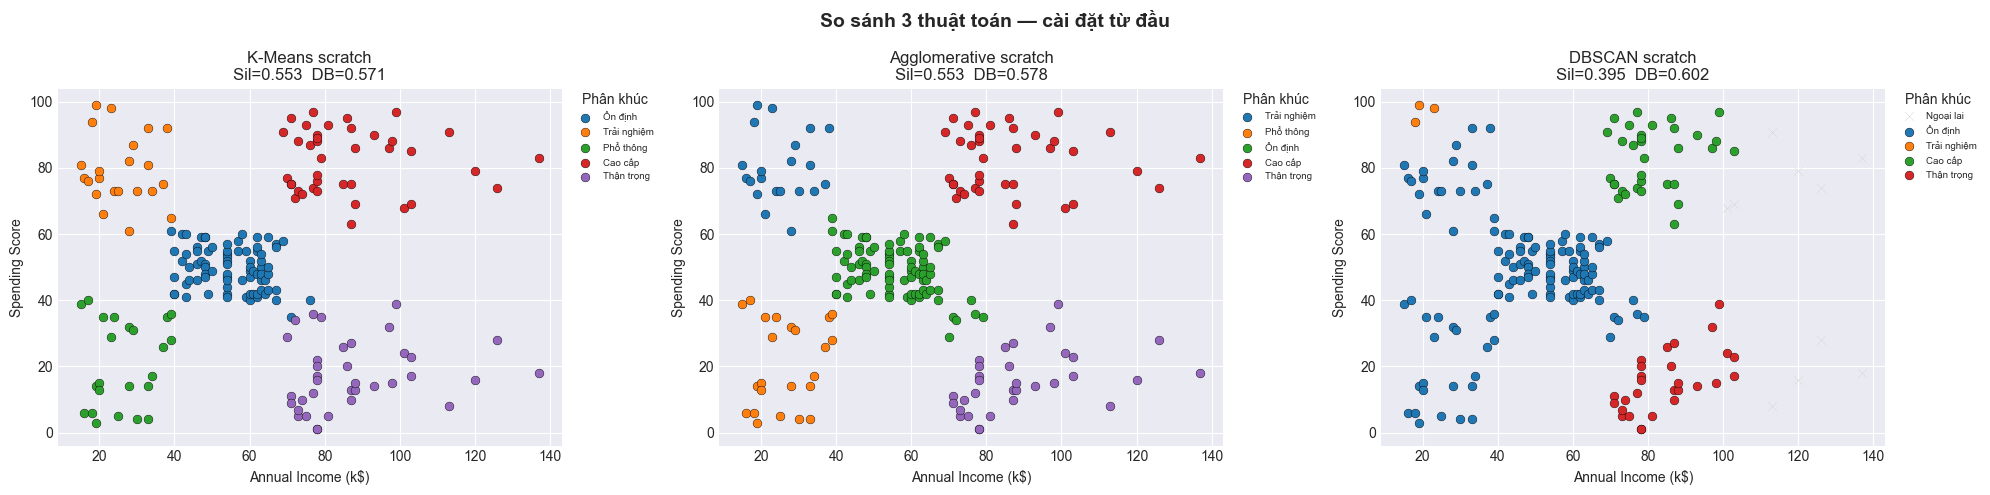

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

results = [
    ('K-Means scratch',       km_best.labels_, cluster_names),
    ('Agglomerative scratch', agg_labels,       agg_names),
    ('DBSCAN scratch',        db_labels,        db_names),
]

print(f"{'Thuật toán':<30} {'n_clusters':>10} {'Silhouette':>12} {'Davies-Bouldin':>15}")
print('-' * 70)

for ax, (title, labels, name_map) in zip(axes, results):
    valid = labels != -1
    n_cl  = len(np.unique(labels[valid]))

    if n_cl >= 2:
        sil = silhouette_score(X3[valid], labels[valid])
        db  = davies_bouldin_score(X3[valid], labels[valid])
        print(f"{title:<30} {n_cl:>10} {sil:>12.4f} {db:>15.4f}")
    else:
        sil, db = 0, 0
        print(f"{title:<30} {'<2 cụm':>10}")

    unique_labels = np.unique(labels)
    colors = {lbl: PALETTE[i % len(PALETTE)]
              for i, lbl in enumerate(l for l in unique_labels if l != -1)}
    for label in unique_labels:
        if label == -1:
            color, marker = 'lightgray', 'x'
            # Rút gọn tên cho biểu đồ so sánh
            lbl_name = 'Ngoại lai'
        else:
            color  = colors[label]
            marker = 'o'
            full_name = (name_map[int(label)] if name_map and int(label) in name_map
                         else f'C{label}')
            lbl_name = full_name.replace('Khách hàng ', '')
        mask = labels == label
        ax.scatter(X3[mask, 0], X3[mask, 1], c=color, marker=marker,
                   s=40, label=lbl_name,
                   edgecolors=('none' if label == -1 else 'k'), linewidths=0.3)
    ax.set_title(f'{title}\nSil={sil:.3f}  DB={db:.3f}')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score')
    ax.legend(title='Phân khúc', fontsize=7,
              bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.suptitle('So sánh 3 thuật toán — cài đặt từ đầu', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Kết luận

| Thuật toán | Ưu điểm | Nhược điểm |
|---|---|---|
| **K-Means** | Nhanh, dễ triển khai, kết quả tốt | Cần biết trước K, nhạy cảm với outlier |
| **Agglomerative** | Không cần K trước, dendrogram trực quan | Chậm O(n³), tốn bộ nhớ |
| **DBSCAN** | Phát hiện noise, không cần K | Khó chọn eps/min_samples, kém với mật độ không đồng đều |

**Kết quả tốt nhất** trên dataset Mall Customers: **K-Means với k=5 trên (Annual Income × Spending Score)**.

---
## Biểu đồ 2D Kết quả Phân Cụm (từng cặp đặc trưng)

Trực quan hóa ba cặp: **Annual Income × Spending Score**, **Age × Annual Income**, **Age × Spending Score** cho cả ba thuật toán.

In [27]:
age    = df["Age"].values
income = df["Annual Income (k$)"].values
score  = df["Spending Score (1-100)"].values


def plot_2d_pairs(labels, title, name_map=None):
    """Vẽ 3 scatter 2D theo từng cặp đặc trưng, tô màu theo cụm."""
    pairs = [
        (income, score,  "Annual Income (k$)", "Spending Score (1-100)"),
        (age,    income, "Age",                "Annual Income (k$)"),
        (age,    score,  "Age",                "Spending Score (1-100)"),
    ]
    unique_labels = sorted(set(labels))
    color_map = {lbl: PALETTE[i % len(PALETTE)]
                 for i, lbl in enumerate(l for l in unique_labels if l != -1)}
    if -1 in unique_labels:
        color_map[-1] = "lightgray"

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, (xdata, ydata, xlabel, ylabel) in zip(axes, pairs):
        for lbl in unique_labels:
            mask = labels == lbl
            if name_map and lbl in name_map:
                display_name = name_map[lbl]
            elif lbl == -1:
                display_name = "Điểm ngoại lai"
            else:
                display_name = f"Cụm {lbl}"
            ax.scatter(
                xdata[mask], ydata[mask],
                label=display_name,
                color=color_map[lbl],
                marker=("x" if lbl == -1 else "o"),
                alpha=0.55, s=40,
                edgecolors=("none" if lbl == -1 else "k"),
                linewidths=0.4,
                zorder=(1 if lbl == -1 else 2),
            )
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(f"{xlabel} vs {ylabel}")
        ax.legend(title="Phân khúc", bbox_to_anchor=(1.02, 1), loc="upper left",
                  fontsize=8, markerscale=1.5, borderaxespad=0)

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("Hàm plot_2d_pairs đã sẵn sàng!")

Hàm plot_2d_pairs đã sẵn sàng!


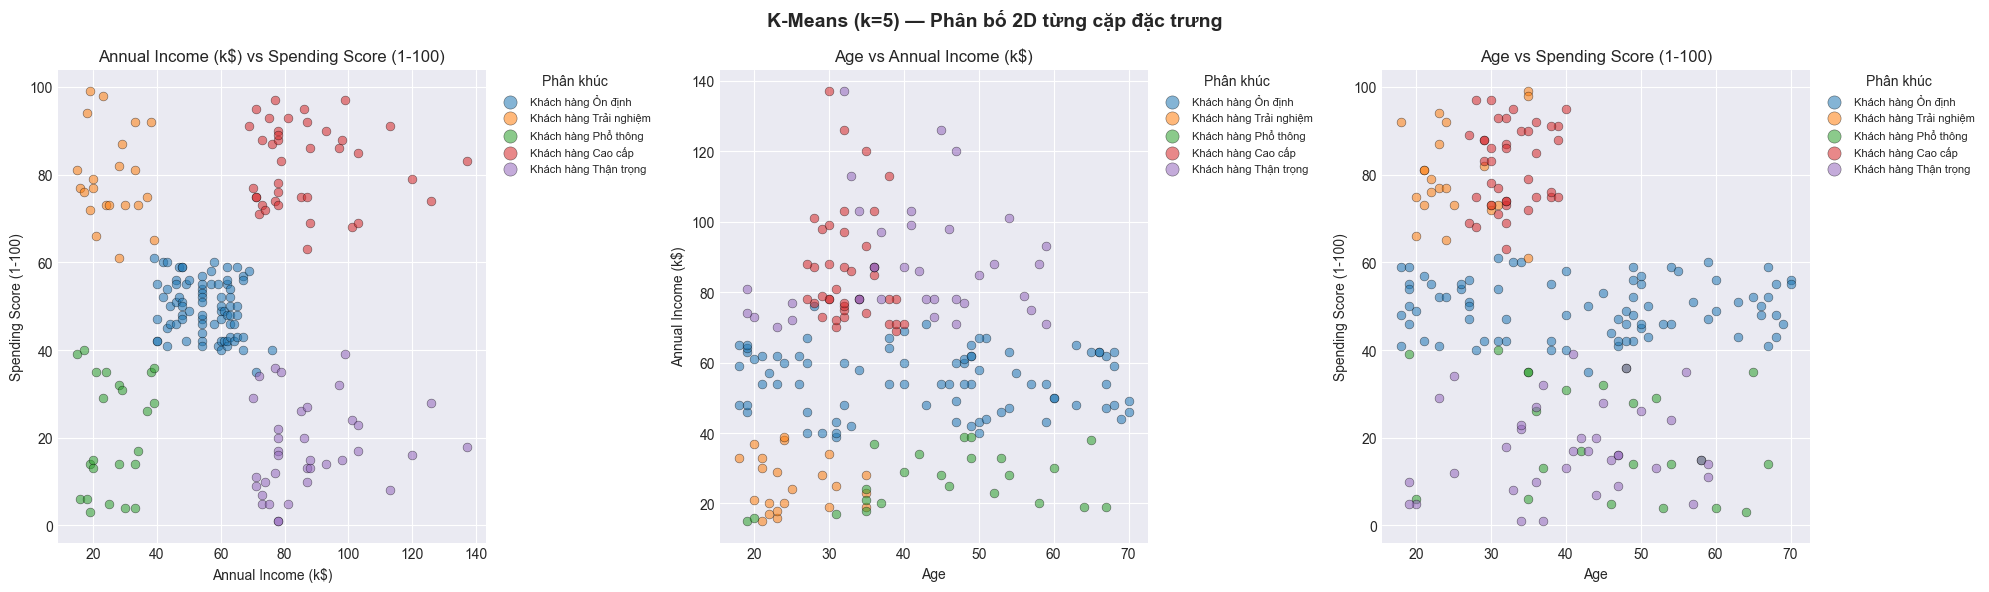

In [28]:
plot_2d_pairs(km_best.labels_, "K-Means (k=5) — Phân bố 2D từng cặp đặc trưng", cluster_names)

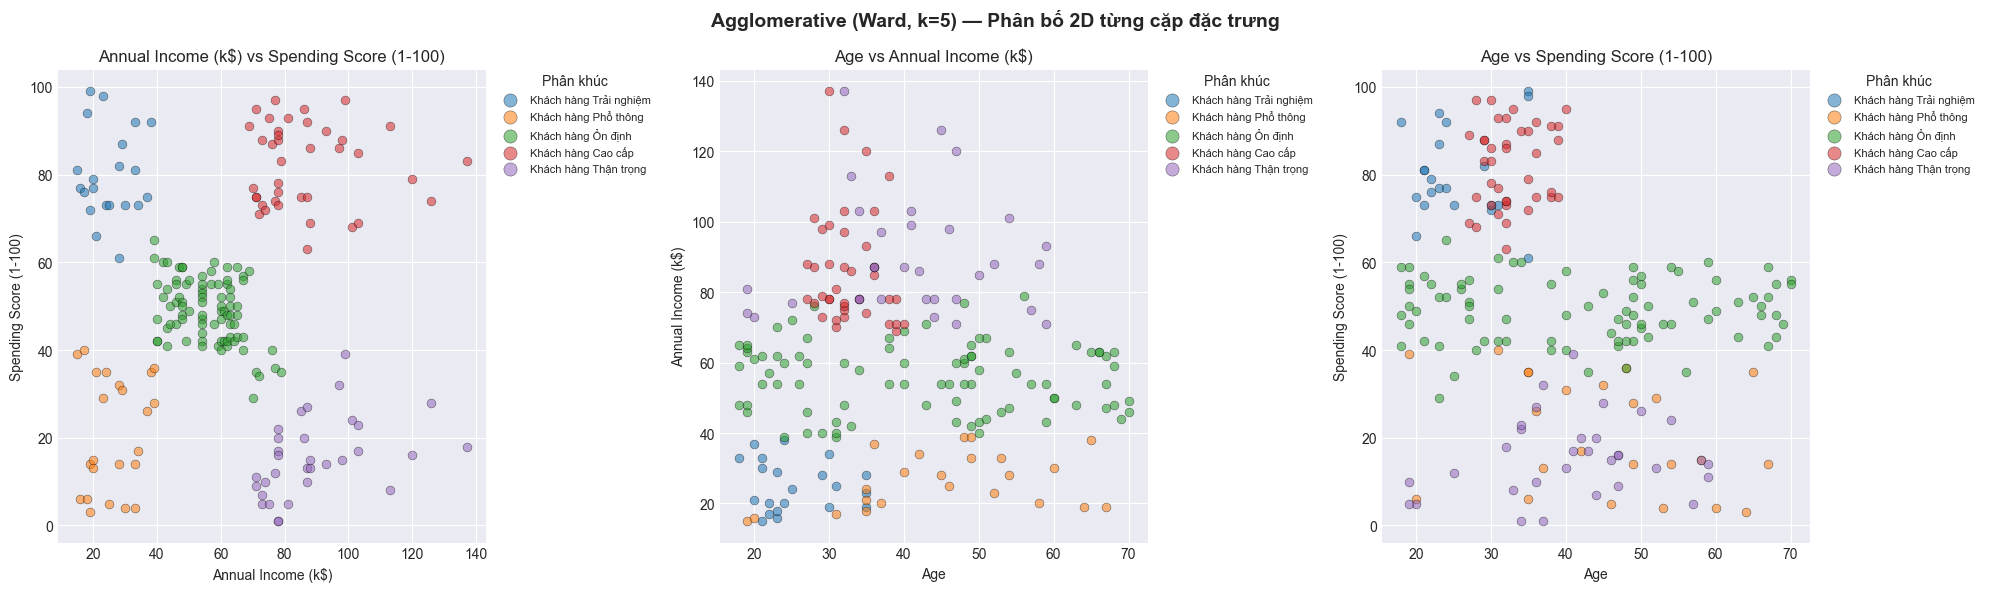

In [29]:
plot_2d_pairs(agg_labels, "Agglomerative (Ward, k=5) — Phân bố 2D từng cặp đặc trưng", agg_names)

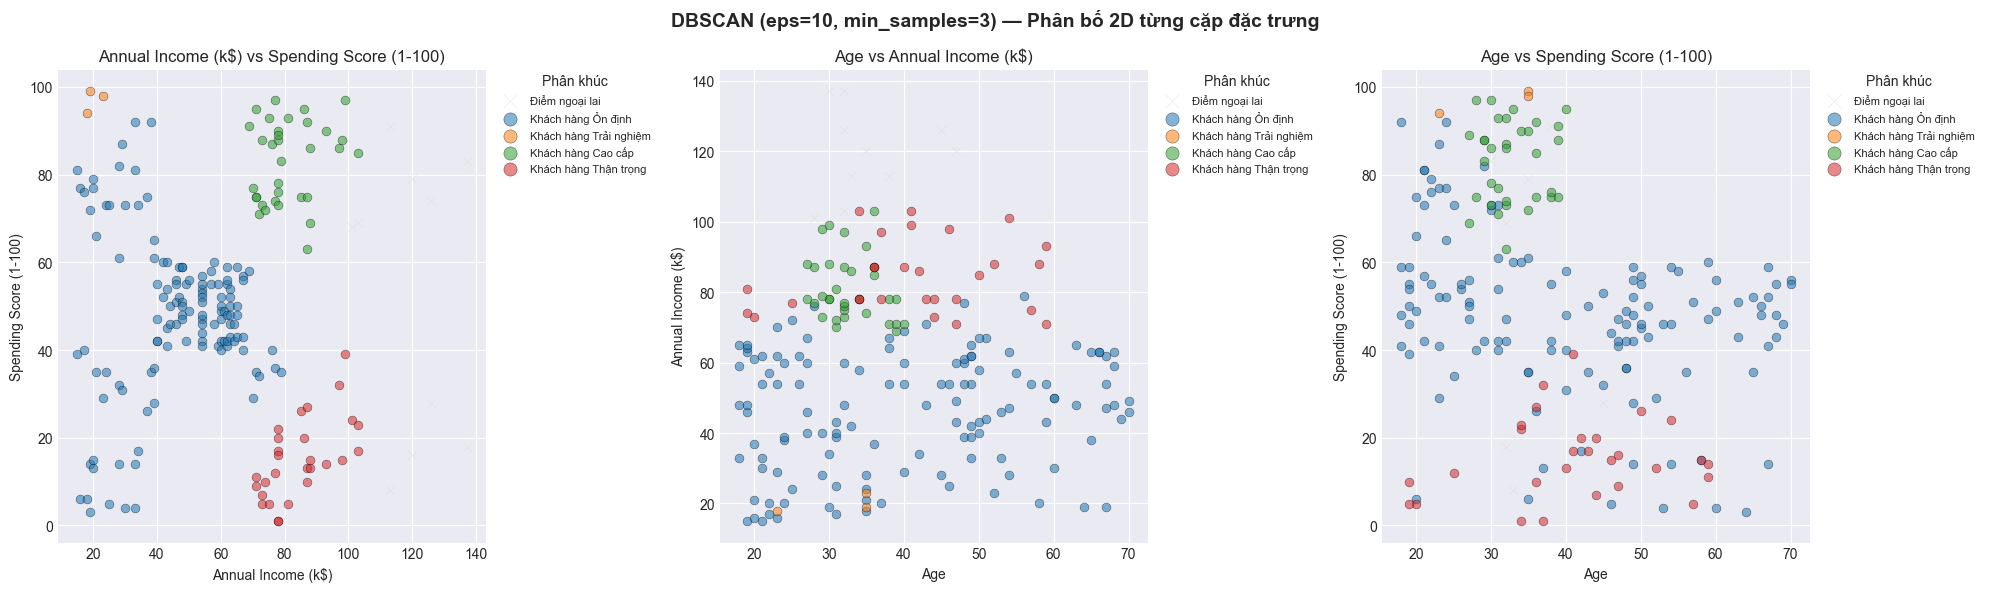

In [30]:
plot_2d_pairs(db_labels, "DBSCAN (eps=10, min_samples=3) — Phân bố 2D từng cặp đặc trưng", db_names)